In [1]:
import os
os.chdir('../../..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from scipy.spatial.distance import pdist, squareform
from umap import UMAP
import kmedoids
import chemiscope
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from src.datasets import QM9Dataset
from src.features import MolecularFeaturizer
from src.non_euclidean import Grassmann

In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_soap()

2026-03-16 12:51:39.774 | INFO     | src.datasets:load:109 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-16 12:51:39.782 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-16 12:51:44.676 | SUCCESS  | src.datasets:add_soap:362 - Added SOAP embeddings.


In [18]:
qm9.df.head(3)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_0""","""CH4""","""[H]C([H])([H])[H]""","""[H]C([H])([H])[H]""","""[H][C][Branch1][C][H][Branch1]…","""""",5,"""Acyclic""",16,0,0,1,0,0,0,0.0,0.0,1.0,0,0,1,0,0,1,2,9,0,0,0,0,0,0,0,0,0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0.184413, 0.478464, … 0.0]"
"""qm9_1""","""H3N""","""[H]N([H])[H]""","""[H]N([H])[H]""","""[H][N][Branch1][C][H][H]""","""""",4,"""Acyclic""",17,0,35,1,0,0,0,0.0,0.0,0.0,1,1,1,0,0,0,2,6,0,0,0,0,0,0,0,0,0,0,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0.170095, 0.427155, … 0.0]"
"""qm9_2""","""H2O""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""","""""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,2,3,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0.150713, 0.392522, … 0.0]"


In [36]:
# add molecular formula to find isomers
df = qm9.df

min_isomers = 30
formula_counts = df.group_by("formula").len().sort("len", descending=True)

display(formula_counts.head(10))

eligible = formula_counts.filter(pl.col("len") >= min_isomers)
if eligible.is_empty():
    raise ValueError(f"No formulas found with at least {min_isomers} isomers")

target_formula = eligible.row(3)[0]

isomers_df = df.filter(pl.col("formula") == target_formula).head(25)
print(f"Selected formula: {target_formula} (n={isomers_df.height})")

formula,len
str,u32
"""C6H10O""",89
"""C5H10O2""",78
"""C5H8O2""",78
"""C5H7NO""",75
"""C6H12O""",62
"""C4H5NO2""",52
"""C6H8O""",51
"""C4H6N2O""",51
"""C4H7NO2""",50


Selected formula: C5H7NO (n=25)


In [37]:
isomers_df.head(5)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_777""","""C5H7NO""","""[H]O/N=C(/C#CC([H])([H])[H])C(…","""[H]O/N=C(/C#CC([H])([H])[H])C(…","""[H][O][/N][=C][Branch1][O][/C]…","""""",14,"""Acyclic""",97,0,32,7,0,0,2,0.4,0.2,0.4,1,2,3,2,1,2,7,24,0,0,0,0,0,0,0,0,0,0,2,0.9081,69.690002,-6.11712,-0.582324,5.534796,1093.150146,3.00079,-8830.619141,-8830.381836,-8830.356445,-8831.587891,28.750999,-58.09811,-58.400429,-58.734558,-54.242336,7.73481,1.18757,1.0428,"[0.11563, 0.30842, … 0.0]"
"""qm9_778""","""C5H7NO""","""[H]C#CC([H])([H])/C(=N/O[H])C(…","""[H]C#CC([H])([H])/C(=N/O[H])C(…","""[H][C][#C][C][Branch1][C][H][B…","""""",14,"""Acyclic""",97,0,32,7,0,0,3,0.4,0.2,0.4,1,2,3,2,1,2,7,24,0,0,0,0,0,0,0,0,0,0,2,0.4796,62.57,-6.781077,0.176874,6.95523,906.438171,2.998123,-8830.261719,-8830.038086,-8830.012695,-8831.15625,28.728001,-57.740089,-58.056259,-58.390388,-53.810444,6.12319,1.43744,1.3165,"[0.11584, 0.313111, … 0.0]"
"""qm9_792""","""C5H7NO""","""[H]C#C/C(=N/O[H])C([H])([H])C(…","""[H]C#C/C(=N/O[H])C([H])([H])C(…","""[H][C][#C][/C][=Branch1][Ring2…","""""",14,"""Acyclic""",97,0,32,7,0,0,3,0.4,0.2,0.4,1,2,3,2,1,2,6,24,0,0,0,0,0,0,0,0,0,0,2,0.6625,64.809998,-6.484473,-0.843553,5.638199,830.600098,3.020409,-8830.241211,-8830.025391,-8829.999023,-8831.118164,28.334,-57.719547,-58.043087,-58.37719,-53.772041,3.52485,2.14842,1.44961,"[0.115958, 0.31265, … 0.0]"
"""qm9_822""","""C5H7NO""","""[H]OC1=C([H])N([H])C(C([H])([H…","""[H]Oc1c([H])c(C([H])([H])[H])n…","""[H][O][C][C][Branch1][C][H][=C…","""phenol""",14,"""Aromatic""",97,1,36,7,1,1,2,0.0,0.8,0.2,2,1,6,0,4,1,6,26,0,0,1,0,0,0,0,0,0,0,2,1.9591,60.27,-4.879001,1.355127,6.231407,767.312012,3.097145,-8833.147461,-8832.953125,-8832.927734,-8833.990234,26.021,-60.626102,-60.971252,-61.305382,-56.644669,6.99764,1.96734,1.55044,"[0.116219, 0.315014, … 0.0]"
"""qm9_825""","""C5H7NO""","""[H]OC1=C([H])C(C([H])([H])[H])…","""[H]Oc1c([H])c(C([H])([H])[H])c…","""[H][O][C][=C][Branch1][C][H][C…","""phenol""",14,"""Aromatic""",97,1,36,7,1,1,2,0.0,0.8,0.2,2,1,6,0,4,1,6,26,0,0,1,0,0,0,0,0,0,0,2,0.8606,59.720001,-4.849069,1.83949,6.688559,766.91217,3.097989,-8833.202148,-8833.010742,-8832.984375,-8834.036133,26.021,-60.680931,-61.028397,-61.362499,-56.690086,7.07489,1.96699,1.55388,"[0.116203, 0.315136, … 0.0]"


In [38]:
original_df = qm9.df
qm9.df = isomers_df
frames = qm9.get_positions(
    subset_size=isomers_df.height,
    output_filename="qm9_isomers.xyz"
)
qm9.df = original_df

print(f"Generated {len(frames)} frames for isomer set")

2026-03-16 13:22:07.436 | SUCCESS  | src.datasets:get_positions:637 - Saved 25 molecules to data/QM9/qm9_isomers.xyz (failed: 0, requested: 25).


Generated 25 frames for isomer set


In [39]:
# grassmann distance on ASE frames
grassmann_dist = Grassmann.distance_matrix(frames)

# SOAP features from SMILES
soap_series = MolecularFeaturizer.compute_soap(isomers_df["canonical_smiles"])
soap_list = soap_series.to_list()

valid_idx = [i for i, v in enumerate(soap_list) if v is not None]

if len(valid_idx) < 3:
    raise ValueError("Too few valid SOAP features to cluster")

isomers_df = isomers_df[valid_idx]

frames = [frames[i] for i in valid_idx]
grassmann_dist = grassmann_dist[np.ix_(valid_idx, valid_idx)]

2026-03-16 13:22:09.387 | INFO     | src.non_euclidean:distance_matrix:301 - Computing Grassmann distance matrix for 25 frames (k=3, method='svd').
Grassmann distances: 100%|██████████| 300/300 [00:00<00:00, 12643.35pair/s]
2026-03-16 13:22:09.433 | SUCCESS  | src.non_euclidean:distance_matrix:320 - Finished Grassmann distance matrix computation.
2026-03-16 13:22:09.433 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...


In [41]:
soap_dist = squareform(pdist(soap_list, metric='cosine'))

In [40]:
# Define range of k
k_range = range(2, 15)

# Initialize lists for metrics
inertia_grass = []
silhouette_grass = []
ch_grass = []

inertia_soap = []
silhouette_soap = []
ch_soap = []

for k in k_range:
    # Grassmann clustering
    model_grass = kmedoids.KMedoids(n_clusters=k, metric="precomputed", random_state=42)
    labels_grass = model_grass.fit_predict(grassmann_dist)
    medoids_grass = model_grass.medoid_indices_
    
    # Inertia
    inertia = sum(grassmann_dist[i, medoids_grass[labels_grass[i]]] for i in range(len(labels_grass)))
    inertia_grass.append(inertia)
    
    # Silhouette
    sil = silhouette_score(grassmann_dist, labels_grass, metric='precomputed')
    silhouette_grass.append(sil)
    
    # CH
    ch = calinski_harabasz_score(grassmann_dist, labels_grass)
    ch_grass.append(ch)
    
    # SOAP clustering
    model_soap = kmedoids.KMedoids(n_clusters=k, metric="precomputed", random_state=42)
    labels_soap = model_soap.fit_predict(soap_dist)
    medoids_soap = model_soap.medoid_indices_
    
    # Inertia
    inertia = sum(soap_dist[i, medoids_soap[labels_soap[i]]] for i in range(len(labels_soap)))
    inertia_soap.append(inertia)
    
    # Silhouette
    sil = silhouette_score(soap_dist, labels_soap, metric='precomputed')
    silhouette_soap.append(sil)
    
    # CH
    ch = calinski_harabasz_score(soap_dist, labels_soap)
    ch_soap.append(ch)


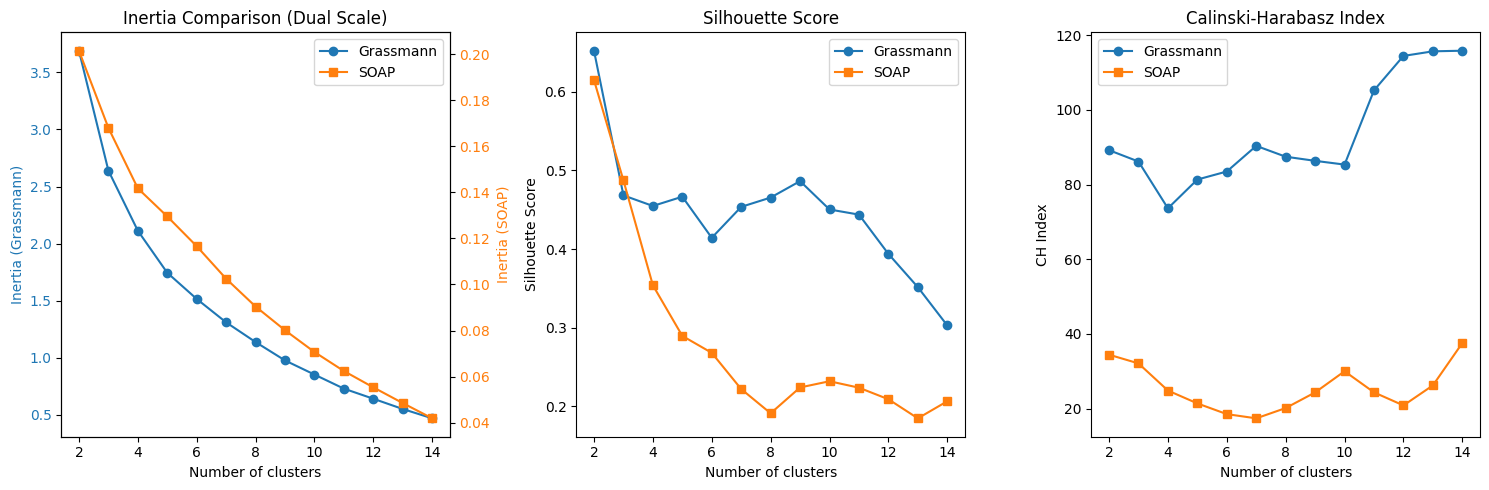

In [42]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Create the first y-axis for Grassmann
ax_grass = axes[0]
line1 = ax_grass.plot(k_range, inertia_grass, label='Grassmann', marker='o', color='tab:blue')
ax_grass.set_ylabel('Inertia (Grassmann)', color='tab:blue')
ax_grass.tick_params(axis='y', labelcolor='tab:blue')

# Create the second y-axis for SOAP
ax_soap = ax_grass.twinx()
line2 = ax_soap.plot(k_range, inertia_soap, label='SOAP', marker='s', color='tab:orange')
ax_soap.set_ylabel('Inertia (SOAP)', color='tab:orange')
ax_soap.tick_params(axis='y', labelcolor='tab:orange')

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_grass.legend(lines, labels, loc='upper right')

ax_grass.set_title('Inertia Comparison (Dual Scale)')
ax_grass.set_xlabel('Number of clusters')

# Silhouette
axes[1].plot(k_range, silhouette_grass, label='Grassmann', marker='o')
axes[1].plot(k_range, silhouette_soap, label='SOAP', marker='s')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

# CH
axes[2].plot(k_range, ch_grass, label='Grassmann', marker='o')
axes[2].plot(k_range, ch_soap, label='SOAP', marker='s')
axes[2].set_title('Calinski-Harabasz Index')
axes[2].set_xlabel('Number of clusters')
axes[2].set_ylabel('CH Index')
axes[2].legend()

plt.tight_layout()
plt.show()

In [43]:
num_clusters_grassmann = [i+2 for i, num in enumerate(silhouette_grass) if num==max(silhouette_grass)][0]
num_clusters_soap = [i+2 for i, num in enumerate(silhouette_soap) if num==max(silhouette_soap)][0]

print(f"Number of clusters for Grassmann: {num_clusters_grassmann} \nNumber of clusters for SOAP: {num_clusters_soap}")

Number of clusters for Grassmann: 2 
Number of clusters for SOAP: 2


In [44]:
def cluster_precomputed(dist_matrix: np.ndarray, n_clusters: int):
    model = kmedoids.KMedoids(n_clusters=n_clusters, metric="precomputed", random_state=42)
    return model.fit_predict(dist_matrix)

labels_grass = cluster_precomputed(grassmann_dist, n_clusters=num_clusters_grassmann)
labels_soap = cluster_precomputed(soap_dist, n_clusters=num_clusters_soap)

isomers_df = isomers_df.with_columns([
    pl.Series("cluster_grass", labels_grass),
    pl.Series("cluster_soap", labels_soap)
])

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
X_grass = reducer.fit_transform(grassmann_dist)

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
X_soap = reducer.fit_transform(soap_dist)

In [45]:
print("--- Grassmann Clustering Results ---")
for cluster_id in range(num_clusters_grassmann):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_grass") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

print("\n" + "="*50 + "\n")

print("--- SOAP Clustering Results ---")
for cluster_id in range(num_clusters_soap):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_soap") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

--- Grassmann Clustering Results ---

Cluster 0:
  - [H]C#CC([H])([H])/C(=N/O[H])C([H])([H])[H]
  - [H]C#C/C(=N/O[H])C([H])([H])C([H])([H])[H]
  - [H]OC1=C([H])N([H])C(C([H])([H])[H])=C1[H]
  - [H]OC1=C([H])C(C([H])([H])[H])=C([H])N1[H]
  - [H]C1=C(N([H])[H])OC(C([H])([H])[H])=C1[H]
  - [H]OC1=C([H])C([H])=C(C([H])([H])[H])N1[H]
  - [H]OC1=C([H])N(C([H])([H])[H])C([H])=C1[H]
  - [H]C1=NC(C([H])([H])[H])=C(C([H])([H])[H])O1
  - [H]C1=C([H])C(C([H])([H])[H])=C(N([H])[H])O1
  - [H]OC1=C([H])N([H])C([H])=C1C([H])([H])[H]
  - [H]C1=C(N([H])[H])C(C([H])([H])[H])=C([H])O1
  - [H]C1=C([H])OC(C([H])([H])C([H])([H])[H])=N1
  - [H]C1=C([H])C([H])=C(N([H])C([H])([H])[H])O1
  - [H]C1=C([H])N([H])C(OC([H])([H])[H])=C1[H]
  - [H]OC([H])([H])C1=C([H])C([H])=C([H])N1[H]
  - [H]C1=NC(C([H])([H])C([H])([H])[H])=C([H])O1
  - [H]C1=C([H])C(N([H])C([H])([H])[H])=C([H])O1
  - [H]C1=C([H])N([H])C([H])=C1OC([H])([H])[H]
  - [H]OC([H])([H])C1=C([H])N([H])C([H])=C1[H]

Cluster 1:
  - [H]O/N=C(/C#CC([H])([H])[H])

# Grassmann

In [46]:
properties = {
    "UMAP 1": X_grass[:, 0],
    "UMAP 2": X_grass[:, 1],
    "Cluster": labels_grass,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Branching index": isomers_df["branching_index"].to_list(),
    "Main chain length": isomers_df["main_chain_length"].to_list(),
    "mu": isomers_df["mu"].to_list(),
    "Homo" : isomers_df["homo"].to_list(),
    "Lumo":isomers_df["lumo"].to_list(),
    "gap": isomers_df["gap"].to_list(),
    "r2":isomers_df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 14, 'data': 'structure-0'}, {'size': 14, 'data': 's…

# Riemann

# SOAP

In [16]:
properties = {
    "UMAP 1": X_soap[:, 0],
    "UMAP 2": X_soap[:, 1],
    "Cluster": labels_soap,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…